In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime


In [114]:
# Loading the Dataset

sentiment_df = pd.read_csv("/content/fear_greed_index.csv")
trader_df = pd.read_csv("/content/historical_data.csv")


sentiment_df.info()
trader_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-nu

In [115]:
sentiment_df.head()



,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


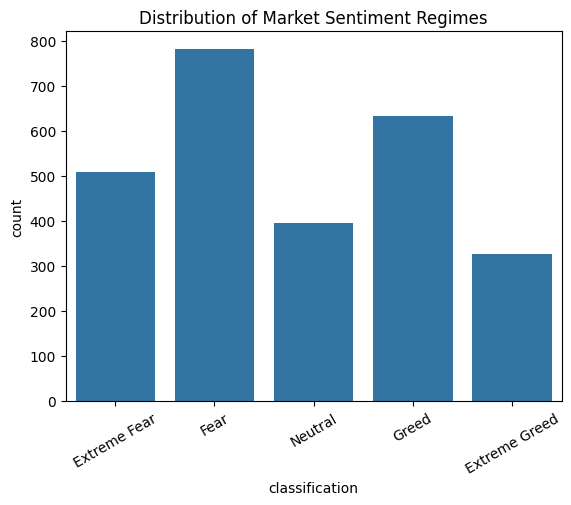

In [116]:
sns.countplot(
    data=sentiment_df,
    x="classification",
    order=["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]
)
plt.title("Distribution of Market Sentiment Regimes")
plt.xticks(rotation=30)
plt.savefig("/content/plots/Distribution of Market Sentiment Regimes.png", dpi=300)
plt.show()


In [117]:
trader_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [118]:
sentiment_df["date"] = pd.to_datetime(sentiment_df["date"])
sentiment_df["trade_date"] = sentiment_df["date"].dt.date
trader_df['Timestamp IST'] = pd.to_datetime(trader_df['Timestamp IST'],dayfirst=True)
trader_df["trade_date"] = trader_df["Timestamp IST"].dt.date
sentiment_mapping = {
    "Extreme Fear": -2,
    "Fear": -1,
    "Neutral": 0,
    "Greed": 1,
    "Extreme Greed": 2
}

sentiment_df["sentiment_score"] = sentiment_df["classification"].map(sentiment_mapping)


In [119]:
trader_df["trade_volume"] = abs(
    trader_df["Size USD"]
)
trader_df["is_profitable"] = trader_df["Closed PnL"] > 0


trader_df["exposure_score"] = abs(
    trader_df["Start Position"] + trader_df["Size Tokens"]
)

trader_df["direction_flag"] = trader_df["Direction"].map({
    "Buy": 1,
    "Sell": -1
})




In [120]:
merged_df = pd.merge(
    trader_df,
    sentiment_df[["trade_date", "classification", "sentiment_score"]],
    on="trade_date",
    how="inner"
)



In [121]:
merged_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Fee,Trade ID,Timestamp,trade_date,trade_volume,is_profitable,exposure_score,direction_flag,classification,sentiment_score
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,...,0.345404,8.950000e+14,1.730000e+12,2024-12-02,7872.16,False,986.870000,1.0,Extreme Greed,2
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,...,0.005600,4.430000e+14,1.730000e+12,2024-12-02,127.68,False,1002.524596,1.0,Extreme Greed,2
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,...,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1150.63,False,1146.608996,1.0,Extreme Greed,2
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,...,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1142.04,False,1289.538564,1.0,Extreme Greed,2
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,...,0.003055,1.050000e+15,1.730000e+12,2024-12-02,69.75,False,1298.218521,1.0,Extreme Greed,2


In [122]:
merged_df.groupby("classification")["Closed PnL"].mean()


,Closed PnL
classification,
Extreme Fear,34.537862
Extreme Greed,67.892861
Fear,54.290400
Greed,42.743559
Neutral,34.307718


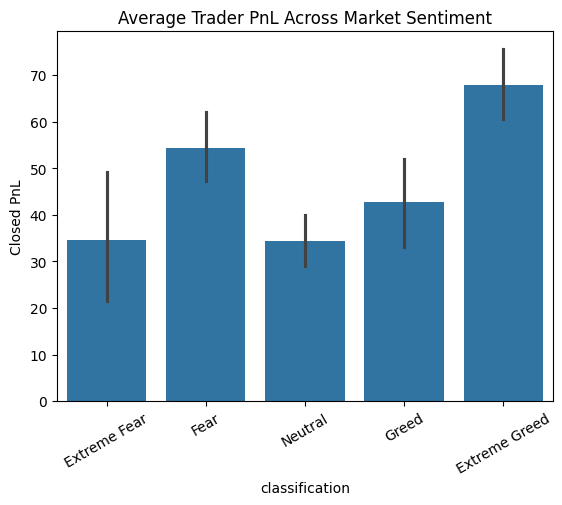

In [123]:
sns.barplot(
    data=merged_df,
    x="classification",
    y="Closed PnL",
    order=["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]
)
plt.title("Average Trader PnL Across Market Sentiment")
plt.xticks(rotation=30)
plt.savefig("/content/plots/avg_pnl_vs_sentiment.png", dpi=300)
plt.show()

In [124]:
merged_df.groupby("classification")["is_profitable"].mean()


,is_profitable
classification,
Extreme Fear,0.370607
Extreme Greed,0.464943
Fear,0.420768
Greed,0.384828
Neutral,0.396991


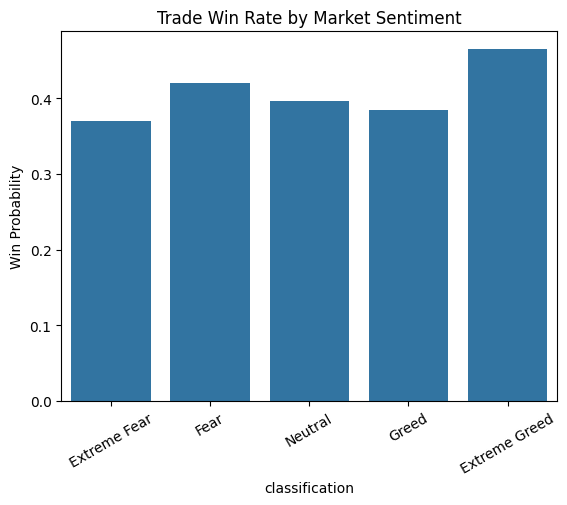

In [125]:
win_rate = (
    merged_df.groupby("classification")["is_profitable"]
    .mean()
    .reset_index()
)

sns.barplot(
    data=win_rate,
    x="classification",
    y="is_profitable",
    order=["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]
)
plt.title("Trade Win Rate by Market Sentiment")
plt.ylabel("Win Probability")
plt.xticks(rotation=30)
plt.savefig("/content/plots/Trade Win Rate by Market Sentiment.png", dpi=300)
plt.show()

In [126]:
merged_df.groupby("classification")["trade_volume"].mean()


,trade_volume
classification,
Extreme Fear,5349.731843
Extreme Greed,3112.251565
Fear,7816.109931
Greed,5736.884375
Neutral,4782.732661


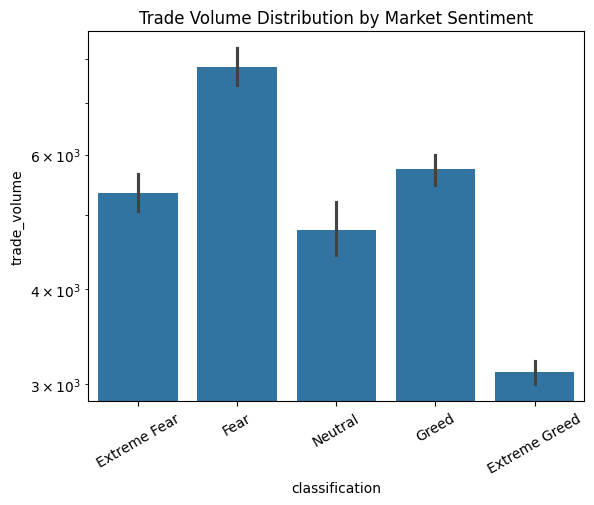

In [127]:
sns.barplot(
    data=merged_df,
    x="classification",
    y="trade_volume",
    order=["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]
)
plt.yscale("log")
plt.title("Trade Volume Distribution by Market Sentiment")
plt.xticks(rotation=30)
plt.savefig("/content/plots/Trade Volume Distribution by Market Sentiment.png", dpi=300)
plt.show()


In [128]:
merged_df.groupby("classification")["exposure_score"].mean()


,exposure_score
classification,
Extreme Fear,58507.333442
Extreme Greed,59701.845625
Fear,84979.192164
Greed,198512.820674
Neutral,92024.530327


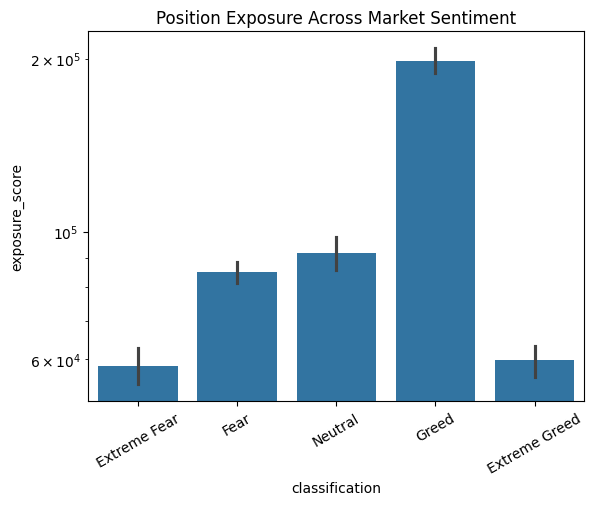

In [129]:
sns.barplot(
    data=merged_df,
    x="classification",
    y="exposure_score",
    order=["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]
)
plt.yscale("log")
plt.title("Position Exposure Across Market Sentiment")
plt.xticks(rotation=30)
plt.savefig("/content/plots/Position Exposure Across Market Sentiment.png", dpi=300)
plt.show()


In [130]:
merged_df.groupby("classification")["direction_flag"].mean()


,direction_flag
classification,
Extreme Fear,-0.127096
Extreme Greed,-0.165257
Fear,-0.023893
Greed,-0.121919
Neutral,0.103040


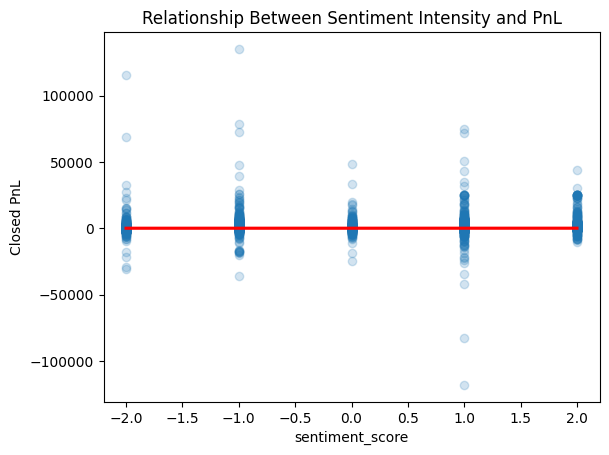

In [131]:
sns.regplot(
    data=merged_df,
    x="sentiment_score",
    y="Closed PnL",
    scatter_kws={"alpha": 0.2},
    line_kws={"color": "red"}
)
plt.title("Relationship Between Sentiment Intensity and PnL")
plt.savefig("/content/plots/Relationship Between Sentiment Intensity and PnL.png", dpi=300)
plt.show()


In [132]:
merged_df[
    ["sentiment_score", "trade_volume", "exposure_score", "Closed PnL"]
].corr()


,sentiment_score,trade_volume,exposure_score,Closed PnL
sentiment_score,1.000000,-0.031912,0.023086,0.005970
trade_volume,-0.031912,1.000000,-0.014790,0.123645
exposure_score,0.023086,-0.014790,1.000000,-0.002222
Closed PnL,0.005970,0.123645,-0.002222,1.000000


In [133]:
merged_df.to_csv(
    "/content/merged_trader_sentiment.csv",
    index=False
)
